# Retirement shock
Compare wages and occupational allocation before and after the change in retirement probabilities.

## 1. Setup
Set figure titles and the age origin once below. Age-group cutoffs are expressed in **years** in this notebook.

In [201]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from main_tenure_sorting import ModelClass, generate_shock
from helper_functions import params_to_latex
from graphs import (
    configure_plots,
    plot_model,
    plot_shock_summary,
    plot_skill_comparison,
    plot_occupation_heatmaps,
)

from graphs import wage_gap_func, _mean_by_age, _distribution_by_age, _legacy_period

import pandas as pd
import numpy as np

SHOW_TITLES = True  # False for figures included in LaTeX
AGE_START = 25
YOUNG_MAX = 35
OLD_MIN = 55
FIRST_PERIOD = 10
SECOND_PERIOD = 20

configure_plots(show_titles=SHOW_TITLES, age_start=AGE_START)
age_groups = dict(young_max=YOUNG_MAX, old_min=OLD_MIN, ages_in_years=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Solve the model and apply the shock
The initial steady state uses the 2008 retirement probabilities. The shock switches to the 2023 probabilities after the first 10 periods (with the default settings).

In [202]:
model = ModelClass()
# Change model.par parameters here before solving.
model.solve(do_print=True)

par = model.par

data_mean_wage = pd.read_csv("Data/wages_by_age_approx.csv")["wage_index_1994"] / 100
data_distribution = pd.read_csv("Data/age_distribution_leaders_approx.csv")["share_1994_pct"]

sim_distribution = _distribution_by_age(model, _legacy_period(model, None), "high") * 100

moment_1 = sim_distribution[:len(data_distribution)] - data_distribution

sim_mean_wage = _mean_by_age(model, _legacy_period(model, None))

moment_2 = sim_mean_wage[:len(data_mean_wage)] - data_mean_wage



# Optional parameter table for LaTeX:
# params_to_latex(par)

model = generate_shock(
    model, first_period=FIRST_PERIOD, second_period=SECOND_PERIOD
)

wage_gap_array = wage_gap_func(model, young_max=YOUNG_MAX - AGE_START, old_min=OLD_MIN - AGE_START)

moment_3 = wage_gap_array[0][-1] - wage_gap_array[0][0]

SSE = np.sum(moment_1**2 + moment_2**2) - moment_3 * 5

print(SSE)

Iteration:  1 eps =  inf
Iteration:  2 eps =  0.989966094017464
Iteration:  3 eps =  1.0
Iteration:  4 eps =  1.0
Iteration:  5 eps =  1.979932188034928
Iteration:  6 eps =  2.9698982820523923
Iteration:  7 eps =  3.959864376069856
Iteration:  8 eps =  3.959864376069856
Iteration:  9 eps =  3.959864376069856
Iteration:  10 eps =  3.959864376069856
Iteration:  11 eps =  3.959864376069856
Iteration:  12 eps =  3.959864376069856
Iteration:  13 eps =  3.9598643760698558
Iteration:  14 eps =  3.9598643760698558
Iteration:  15 eps =  3.9598643760698558
Iteration:  16 eps =  3.9598643760698558
Iteration:  17 eps =  3.9598643760698558
Iteration:  18 eps =  3.9598643760698558
Iteration:  19 eps =  3.9598643760698558
Iteration:  20 eps =  3.9598643760698558
Iteration:  21 eps =  3.9598643760698558
Iteration:  22 eps =  3.9598643760698558
Iteration:  23 eps =  3.9598643760698558
Iteration:  24 eps =  3.9598643760698558
Iteration:  25 eps =  3.9598643760698558
Iteration:  26 eps =  3.9598643760698

In [203]:
moment_3

np.float64(2.6433824411369766)

## 3. Wages and employment
The overview shows the full time paths and age profiles in the final period. The shock summary uses each period's population weights for the old/young wage ratio and age-group wage changes. The wage ratio is old divided by young, expressed as a percentage change from period zero.

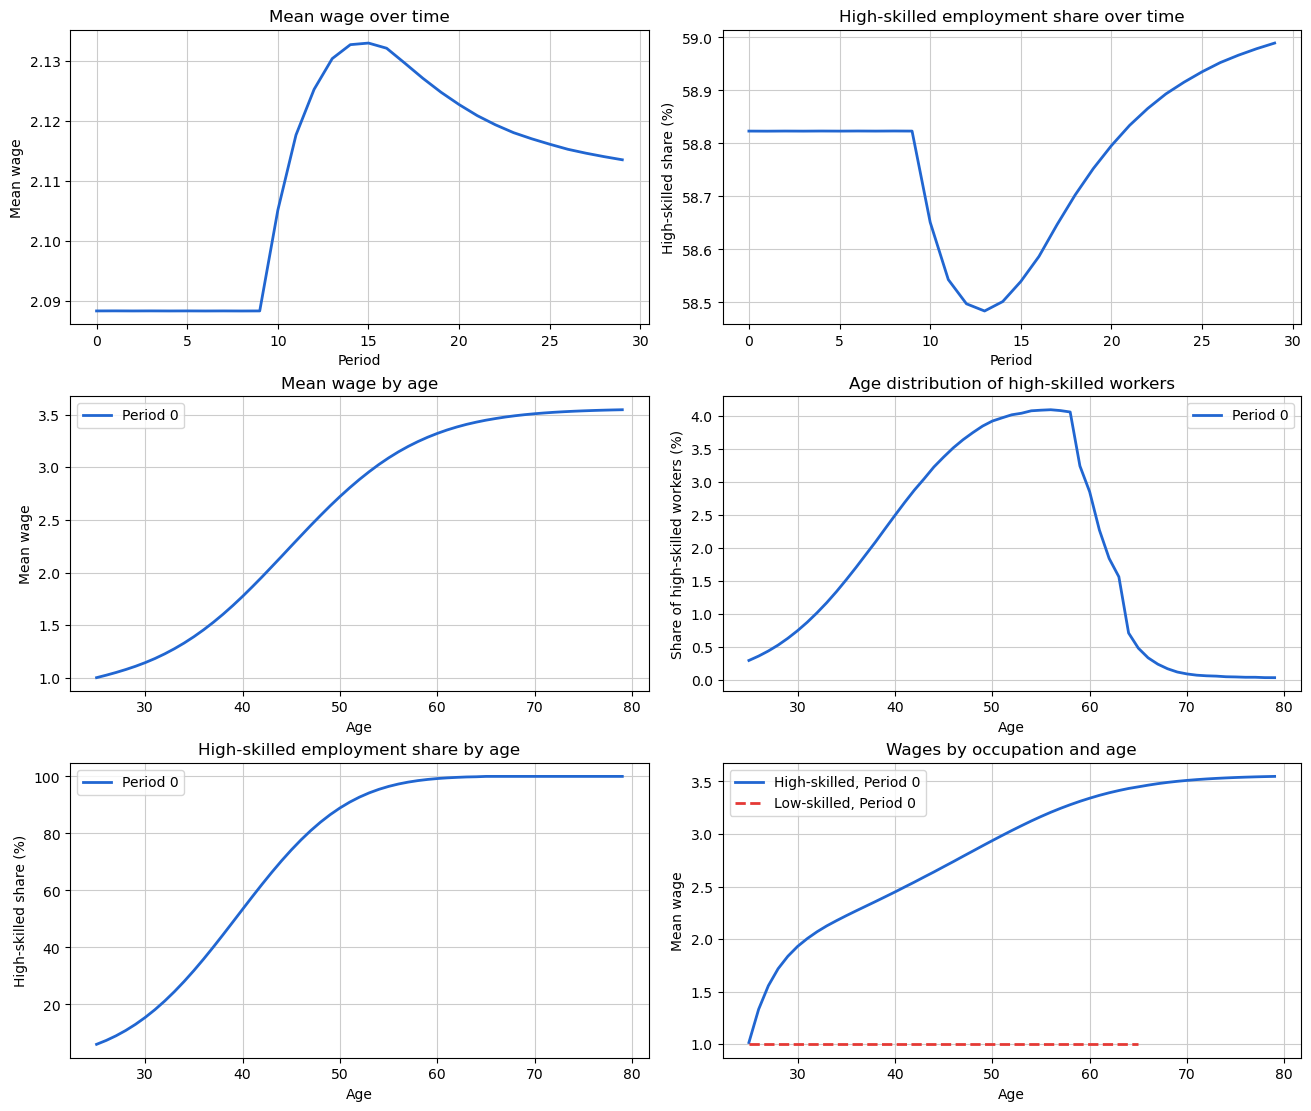

In [204]:
fig_overview, axes_overview = plot_model(model, time = 1)

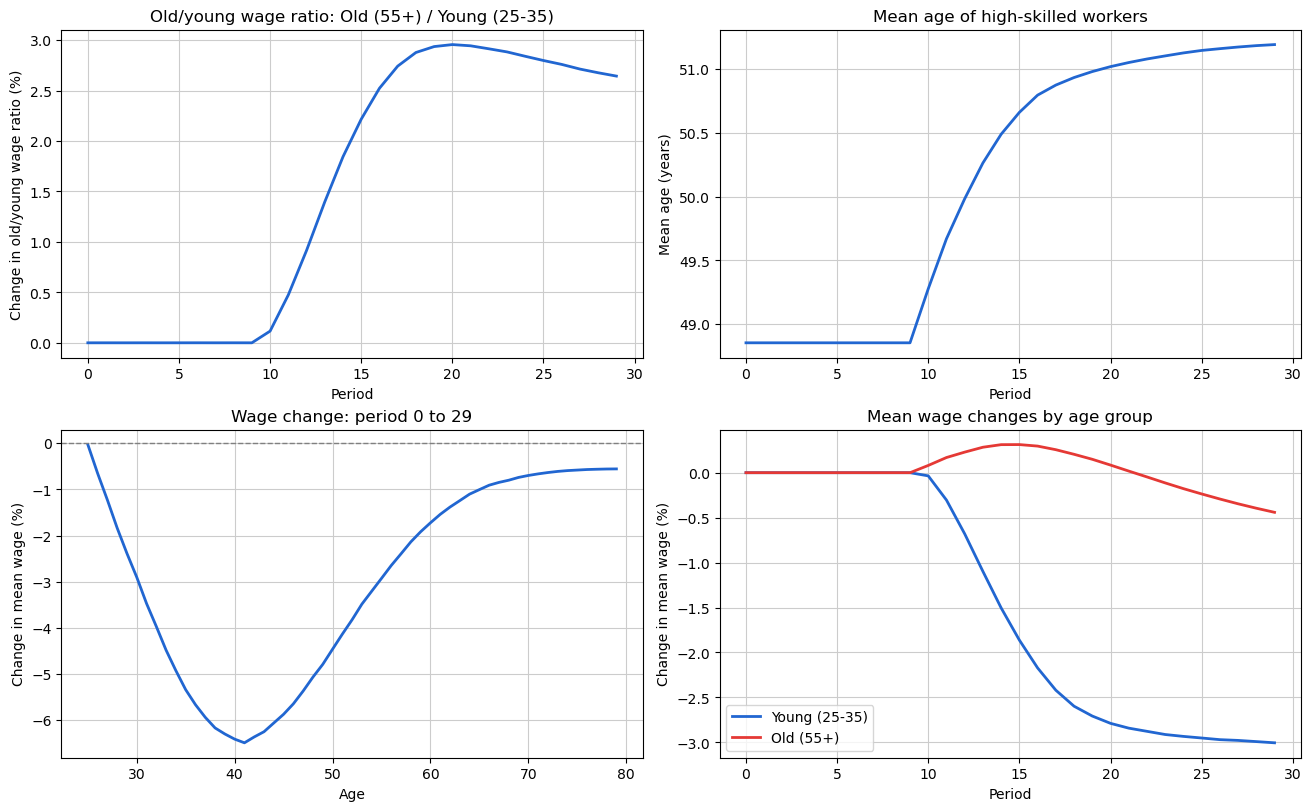

In [205]:
fig_summary, axes_summary = plot_shock_summary(model, **age_groups)

The next figure groups high- and low-skilled wages and employment shares for the same young and old age groups. Each series is indexed to 100 in period zero; an undefined or zero baseline produces a gap.

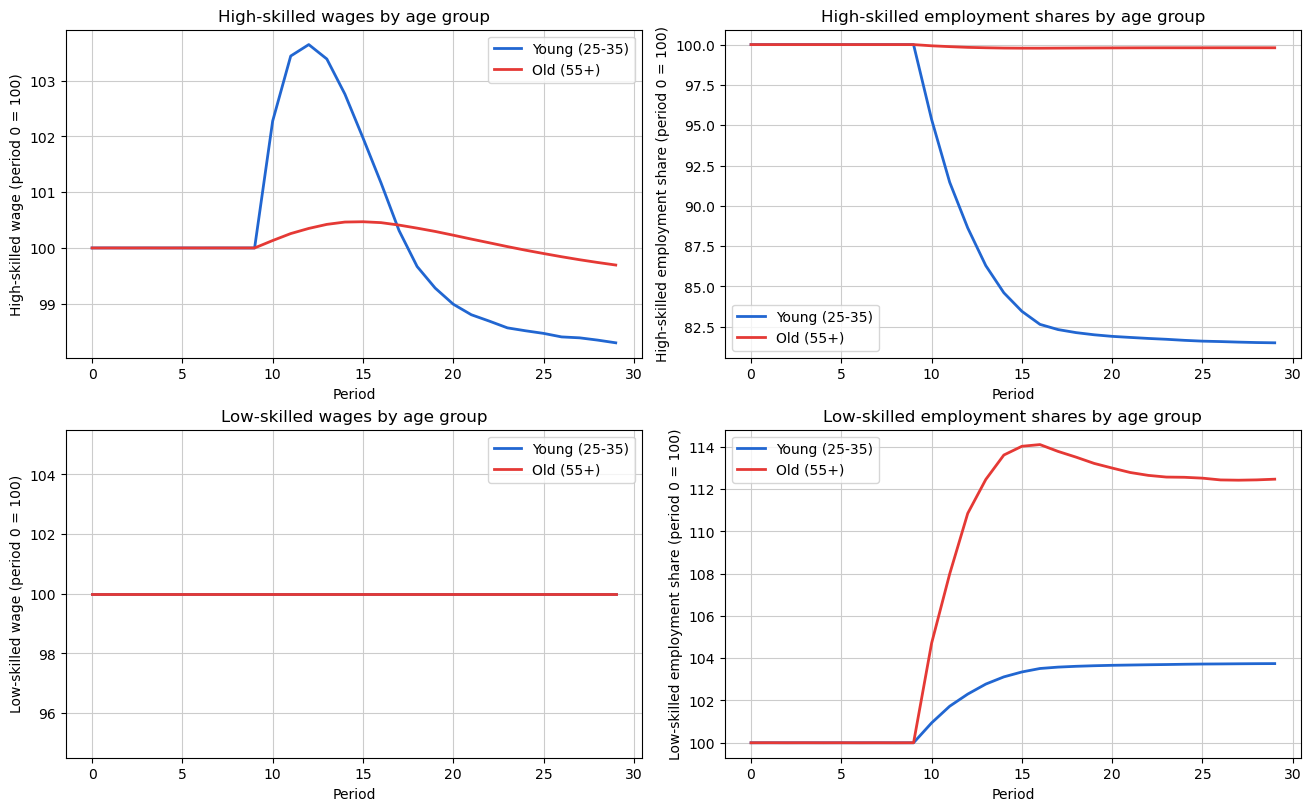

In [206]:
fig_skills, axes_skills = plot_skill_comparison(model, **age_groups, normalize=True)
# Use normalize=False to show wage levels and employment shares in percent.

## 4. Occupational allocation
Red means low-skilled work and blue means high-skilled work. Intermediate colors indicate a split ability bin; gray indicates missing data or no population mass. The third panel subtracts the initial high-job share from the final share, in percentage points.

These compare the same ages and abilities across periods, rather than following the same individuals as they age.

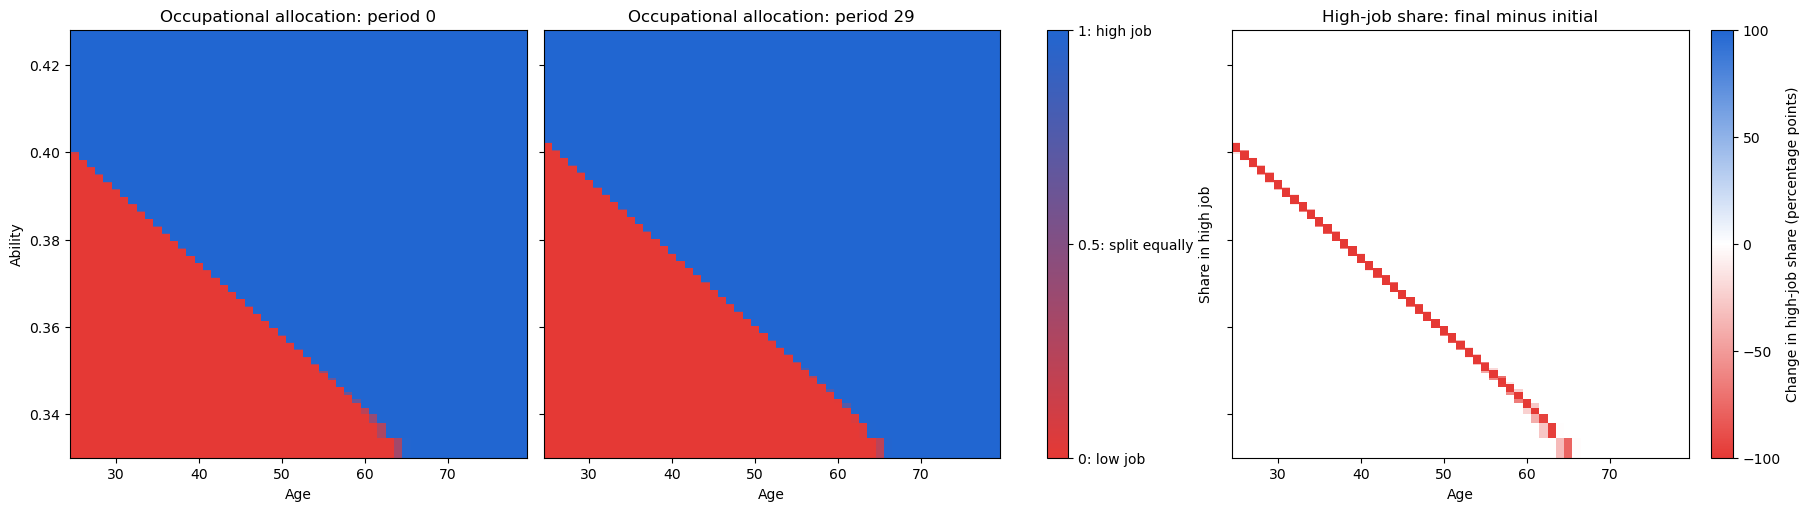

In [207]:
fig_occupations, axes_occupations = plot_occupation_heatmaps(
    model, t_start=0, t_end=-1
)

# Every plot also accepts show_titles=False for an individual figure.
# Example export after disabling titles:
# fig_occupations.savefig("occupational_allocation.pdf", bbox_inches="tight")